In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

In [18]:
import numpy as np
# Vérification des valeurs manquantes
print(df.isnull().sum().sort_values(ascending=False).head(20))
# Remplir certaines colonnes numériques
df["commissioning_year"] = df["commissioning_year"].fillna(
    df["commissioning_year"].median()
)
df["capacity_mw"] = pd.to_numeric(
    df["capacity_mw"],
    errors="coerce"
)
# Vérification
print(df[["capacity_mw", "commissioning_year"]].isnull().sum())

other_fuel3                      34844
other_fuel2                      34660
other_fuel1                      32992
generation_gwh_2013              28519
generation_gwh_2014              27710
generation_gwh_2015              26733
generation_gwh_2016              25792
generation_gwh_2017              25436
generation_gwh_2018              25299
generation_gwh_2019              25277
generation_data_source           23536
year_of_capacity_data            20049
estimated_generation_gwh_2013    18816
wepp_id                          18702
estimated_generation_gwh_2014    18433
estimated_generation_gwh_2015    17886
commissioning_year               17489
estimated_generation_gwh_2016    17366
owner                            14068
estimated_generation_gwh_2017     1798
dtype: int64
capacity_mw           0
commissioning_year    0
dtype: int64


In [19]:
print(df["capacity_mw"].describe())
print("Moyenne :", np.mean(df["capacity_mw"]))
print("Médiane :", np.median(df["capacity_mw"]))
print("Écart-type :", np.std(df["capacity_mw"]))

count    34936.000000
mean       163.355148
std        489.636072
min          1.000000
25%          4.900000
50%         16.745000
75%         75.344250
max      22500.000000
Name: capacity_mw, dtype: float64
Moyenne : 163.35514790637166
Médiane : 16.744999999999997
Écart-type : 489.6290640361989


In [20]:
fuel_counts = df["primary_fuel"].value_counts()
print(fuel_counts.head(10))

primary_fuel
Solar         10665
Hydro          7156
Wind           5344
Gas            3998
Coal           2330
Oil            2320
Biomass        1430
Waste          1068
Nuclear         195
Geothermal      189
Name: count, dtype: int64


In [21]:
country_counts = df["country_long"].value_counts()
print(country_counts.head(10))

country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Name: count, dtype: int64


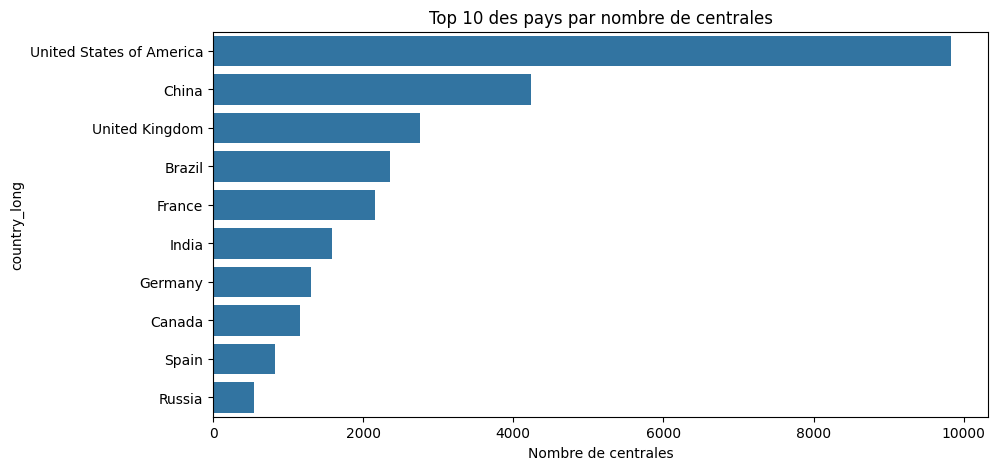

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
top10 = df["country_long"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(
    x=top10.values,
    y=top10.index
)
plt.title("Top 10 des pays par nombre de centrales")
plt.xlabel("Nombre de centrales")
plt.show()

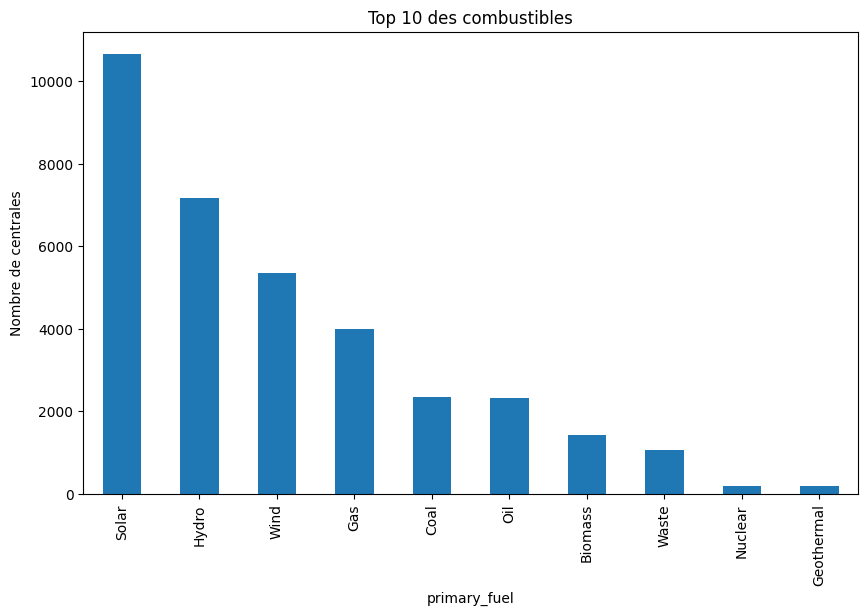

In [23]:
plt.figure(figsize=(10,6))
df["primary_fuel"].value_counts().head(10).plot(
    kind="bar"
)
plt.title("Top 10 des combustibles")
plt.ylabel("Nombre de centrales")
plt.show()

In [24]:
fuel_stats = df.groupby(
    "primary_fuel"
)["capacity_mw"].agg(
    ["mean", "median", "std", "count"]
)
print(fuel_stats)

                       mean      median          std  count
primary_fuel                                               
Biomass           23.972938     9.45000    39.461805   1430
Coal             843.579828   600.00000   888.187187   2330
Cogeneration      98.731707    31.90000   283.428252     41
Gas              373.449375   147.50000   560.934146   3998
Geothermal        67.130952    30.00000   114.640890    189
Hydro            147.171551    20.00000   549.809328   7156
Nuclear         2091.855179  1888.00000  1303.509273    195
Oil              112.878754     9.00000   392.009039   2320
Other             84.020000    40.00000   145.891392     43
Petcoke          202.048125    65.48875   476.986459     12
Solar             17.657039     5.80000    41.939412  10665
Storage           12.683704     4.90000    35.574631    135
Waste             13.809657     4.80000    20.582503   1068
Wave and Tidal    55.220000     5.00000   101.440708     10
Wind              49.224126    27.00000 

In [25]:
from scipy.stats import ttest_ind
coal = df[df["primary_fuel"]=="Coal"]["capacity_mw"]
gas = df[df["primary_fuel"]=="Gas"]["capacity_mw"]
t_stat, p_value = ttest_ind(
    coal,
    gas,
    nan_policy="omit"
)
print("t-statistic =", t_stat)
print("p-value =", p_value)

t-statistic = 25.788324829336716
p-value = 1.5774516338525512e-139


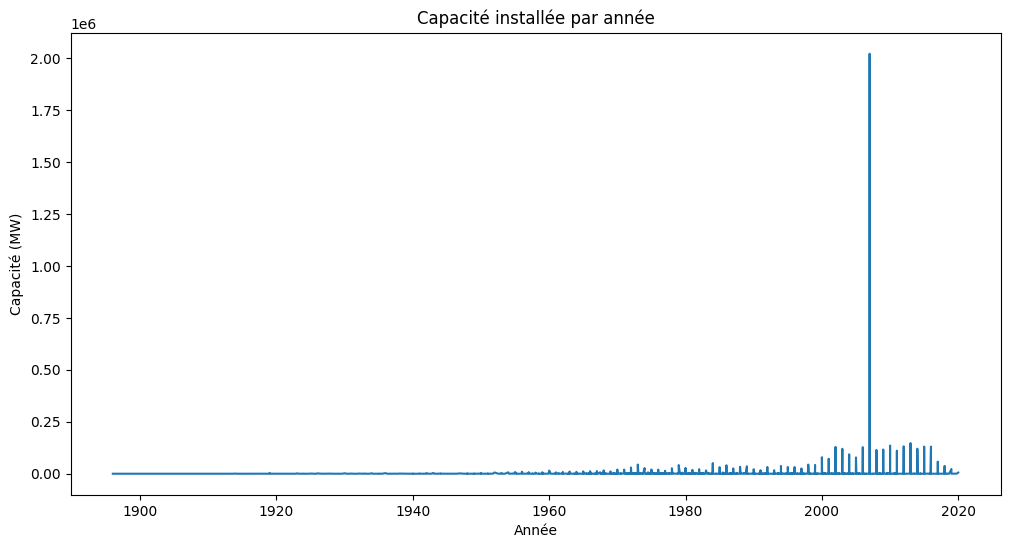

In [27]:
yearly = df.groupby(
    "commissioning_year"
)["capacity_mw"].sum()
plt.figure(figsize=(12,6))
plt.plot(
    yearly.index,
    yearly.values
)
plt.title("Capacité installée par année")
plt.xlabel("Année")
plt.ylabel("Capacité (MW)")
plt.show()

In [28]:
fuel_year = pd.crosstab(
    df["commissioning_year"],
    df["primary_fuel"]
)
fuel_year.tail()

primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wave and Tidal,Wind
commissioning_year,,,,,,,,,,,,,,,
2019.000000,2,0,1,34,2,1,0,2,0,0,458,32,3,0,61
2019.000000,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2019.411765,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2019.796326,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2020.000000,1,0,0,6,0,0,0,0,0,0,122,2,2,0,17


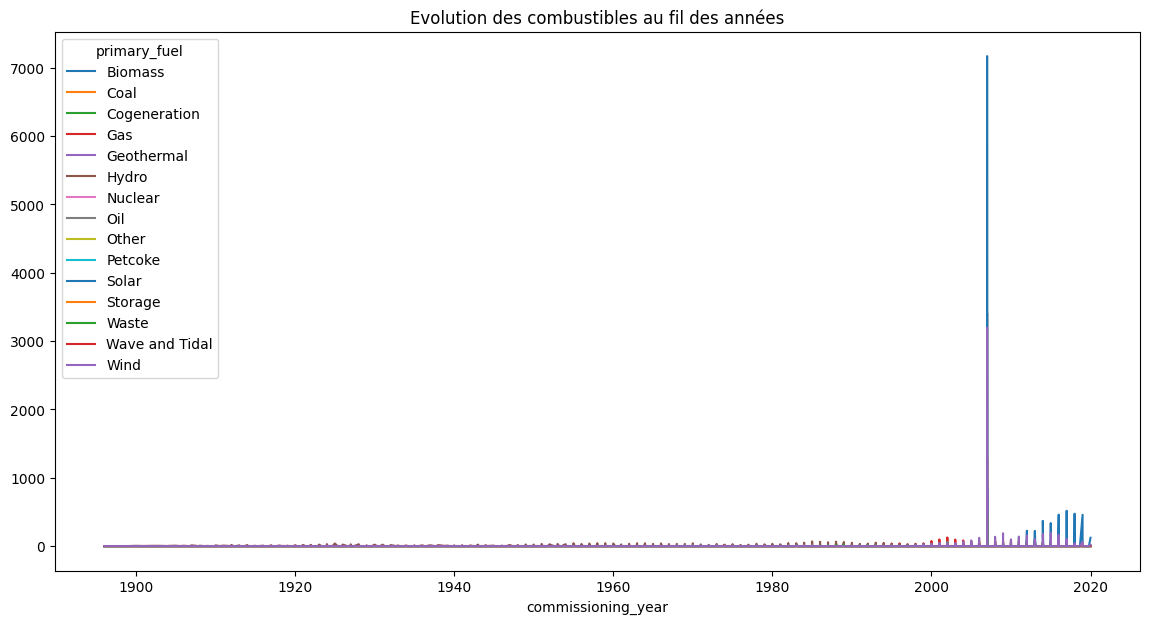

In [29]:
fuel_year.plot(
    figsize=(14,7)
)
plt.title(
    "Evolution des combustibles au fil des années"
)
plt.show()

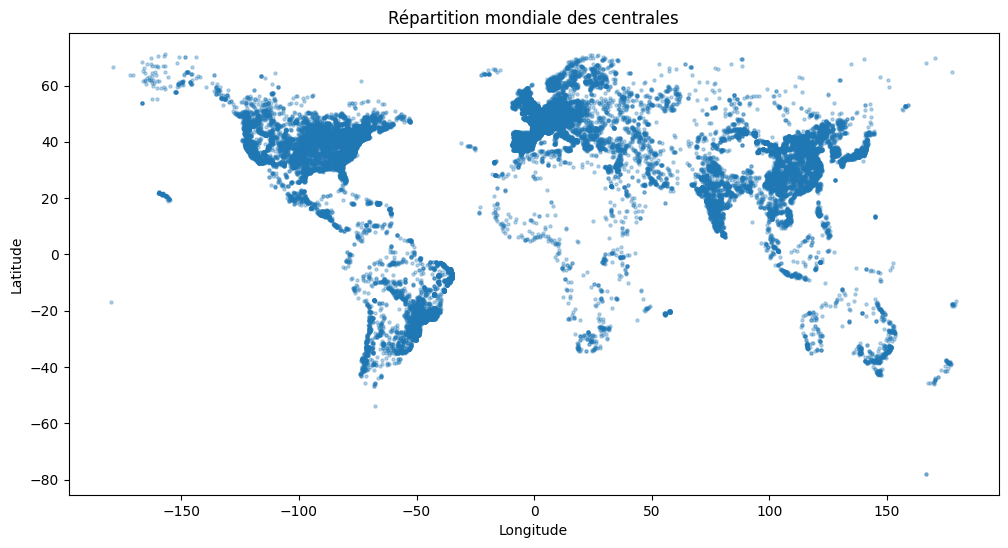

In [30]:
plt.figure(figsize=(12,6))
plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.3,
    s=5
)
plt.title("Répartition mondiale des centrales")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [31]:
numeric_cols = [
    "capacity_mw",
    "latitude",
    "longitude",
    "commissioning_year"
]
matrix = df[numeric_cols].dropna()
corr_matrix = np.corrcoef(matrix.T)
print(corr_matrix)

[[ 1.         -0.01321759  0.15152454 -0.04188333]
 [-0.01321759  1.         -0.06835441 -0.07660014]
 [ 0.15152454 -0.06835441  1.          0.11457598]
 [-0.04188333 -0.07660014  0.11457598  1.        ]]


In [32]:
eigenvalues, eigenvectors = np.linalg.eig(
    corr_matrix
)
print("Valeurs propres")
print(eigenvalues)
print("\nVecteurs propres")
print(eigenvectors)

Valeurs propres
[0.78851653 1.20985542 1.06541451 0.93621355]

Vecteurs propres
[[-0.57277634 -0.42972523 -0.69110682 -0.09815733]
 [ 0.00936521  0.40672558 -0.37872886  0.8312948 ]
 [ 0.66955773 -0.6795584  -0.16767404  0.2485523 ]
 [-0.47279171 -0.43371755  0.59230164  0.48737649]]
